# One-Dimensional CNN for IMDB Sentiment

This notebook explains the main convolutional-network concepts and trains a compact PyTorch 1D CNN on token sequences from the IMDB reviews used throughout the roadmap.

## Convolutional-network concepts

A neural-network layer called a convolution actually computes cross-correlation: it slides a small learned kernel across the input and takes weighted sums without reversing the kernel. The name *convolution* remains standard. Weight sharing lets the same kernel recognize a local pattern wherever it appears.

- **Kernel size** is the width of the local window. In text, a width-five kernel examines five neighboring token embeddings at a time.
- **Stride** is the number of input positions moved between outputs. A larger stride reduces the output length and skips some overlapping windows.
- **Padding** adds values, usually zeros, at the boundaries. With an odd kernel and suitable padding, stride-one convolution can preserve sequence length.
- **Pooling** summarizes nearby or entire feature maps. Max pooling keeps the strongest response, so global max pooling asks whether each learned pattern appeared anywhere in a review.
- **Receptive field** is the region of the original input that can affect one activation. Track its size `r` and the jump `j` between adjacent activations with `r_new = r_old + (kernel - 1) × j_old` and `j_new = j_old × stride`.

For the assigned 2D stack `Conv 3×3 (stride 1) → MaxPool 2×2 (stride 2) → Conv 3×3 (stride 1)`, track one spatial axis at a time, starting with `r = 1` and `j = 1`. The first convolution gives `(r, j) = (3, 1)`, pooling gives `(4, 2)`, and the second convolution gives `(8, 2)`. Each final activation therefore has an **8×8 receptive field**. The analogous 1D stack sees eight input positions.

A 1D CNN moves along one ordered axis, such as time samples or tokens, while its channels hold measurements or embedding dimensions. A 2D CNN moves across height and width, making it natural for images where both spatial axes matter. Dilated, or atrous, convolution spaces the kernel taps apart. A dilation of two uses every other input position, expanding the receptive field without adding kernel weights or reducing the output resolution.

## Experiment design

Reviews that become identical after preprocessing and the fixed 256-token truncation are deduplicated before a stratified 60/20/20 train/validation/test split. The vocabulary is learned from training reviews only, followed by a check that unknown-token mapping creates no cross-split collisions. Architecture, sequence length, learning rate, epoch count, and the 0.5 decision threshold are fixed before training; validation is monitored and the test set is used once for the final report.

In [1]:
from collections import Counter
from itertools import chain
from pathlib import Path
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import torch
from torch import nn

SEED = 42
MAX_SEQUENCE_LENGTH = 256
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
sys.path.insert(0, str(part_02 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")


def model_tokens(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return [
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    ]


imdb["tokens"] = imdb["review"].map(model_tokens)
imdb["model_visible_text"] = (
    imdb["tokens"].str[:MAX_SEQUENCE_LENGTH].str.join(" ")
)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError(
        "Reviews identical after preprocessing and truncation have conflicting labels."
    )

original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)
development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

split_summary = pd.DataFrame(
    {
        "reviews": [len(train), len(validation), len(test)],
        "positive proportion": [
            train["label"].mean(),
            validation["label"].mean(),
            test["label"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,577 (423 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29745,0.5019
validation,9916,0.5019
test,9916,0.5019


## Training-only vocabulary and fixed-length sequences

The sequence representation preserves token order, unlike TF-IDF. Index 0 is reserved for padding and index 1 for tokens outside the training vocabulary. Vocabulary frequency counts come only from the training split. Reviews are right-padded or truncated to 256 tokens, and true lengths are retained so padded convolution positions cannot win global max pooling.

In [2]:
PAD_ID = 0
UNKNOWN_ID = 1
MAX_VOCABULARY_SIZE = 20_000

token_counts = Counter(chain.from_iterable(train["tokens"]))
vocabulary_terms = [
    token
    for token, count in sorted(
        token_counts.items(), key=lambda item: (-item[1], item[0])
    )
    if count >= 2
][:(MAX_VOCABULARY_SIZE - 2)]
vocabulary = {
    token: index + 2 for index, token in enumerate(vocabulary_terms)
}


def encode_reviews(token_lists):
    encoded = np.full(
        (len(token_lists), MAX_SEQUENCE_LENGTH), PAD_ID, dtype=np.int32
    )
    lengths = np.empty(len(token_lists), dtype=np.int64)
    unknown_tokens = 0
    retained_tokens = 0
    for row, tokens in enumerate(token_lists):
        retained = tokens[:MAX_SEQUENCE_LENGTH]
        token_ids = [vocabulary.get(token, UNKNOWN_ID) for token in retained]
        encoded[row, :len(token_ids)] = token_ids
        lengths[row] = len(token_ids)
        unknown_tokens += sum(token_id == UNKNOWN_ID for token_id in token_ids)
        retained_tokens += len(token_ids)
    return encoded, lengths, unknown_tokens / retained_tokens


encoding_start = time.perf_counter()
train_ids, train_lengths, train_unknown_rate = encode_reviews(train["tokens"].tolist())
validation_ids, validation_lengths, validation_unknown_rate = encode_reviews(
    validation["tokens"].tolist()
)
test_ids, test_lengths, test_unknown_rate = encode_reviews(test["tokens"].tolist())
encoded_splits = {
    "train": train_ids,
    "validation": validation_ids,
    "test": test_ids,
}
encoded_rows = {
    name: {row.tobytes() for row in rows}
    for name, rows in encoded_splits.items()
}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert encoded_rows[left].isdisjoint(encoded_rows[right])
encoding_seconds = time.perf_counter() - encoding_start

train_labels = train["label"].to_numpy(dtype=np.float32)
validation_labels = validation["label"].to_numpy(dtype=np.float32)
test_labels = test["label"].to_numpy(dtype=np.float32)

sequence_summary = pd.DataFrame(
    {
        "mean retained length": [
            train_lengths.mean(), validation_lengths.mean(), test_lengths.mean()
        ],
        "truncated proportion": [
            np.mean(train["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
            np.mean(validation["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
            np.mean(test["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
        ],
        "unknown-token rate": [
            train_unknown_rate, validation_unknown_rate, test_unknown_rate
        ],
    },
    index=["train", "validation", "test"],
)

print(f"Vocabulary size including special tokens: {len(vocabulary) + 2:,}")
print(f"Encoded training shape: {train_ids.shape}")
print(f"Sequence encoding time: {encoding_seconds:.2f} seconds")
print("Encoded sequence overlap across splits: 0")
display(sequence_summary.style.format("{:.4f}"))
assert train_lengths.min() >= 1
assert set(vocabulary).isdisjoint({"<pad>", "<unknown>"})

Vocabulary size including special tokens: 20,000
Encoded training shape: (29745, 256)
Sequence encoding time: 1.66 seconds
Encoded sequence overlap across splits: 0


,mean retained length,truncated proportion,unknown-token rate
train,170.5494,0.2562,0.0407
validation,170.3801,0.2603,0.0430
test,169.6033,0.2566,0.0430


## Model

The embedding layer maps token IDs to 64-dimensional vectors. A width-five, stride-one convolution with padding two learns 64 local detectors while preserving the 256-position sequence length. ReLU keeps positive pattern responses, masked global max pooling keeps the strongest valid response per detector, and a linear layer produces one sentiment logit. The model's local convolutional receptive field is five tokens; global pooling then aggregates those local detections across the review.

In [3]:
class SentimentCNN(nn.Module):
    def __init__(self, vocabulary_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocabulary_size, 64, padding_idx=PAD_ID
        )
        self.convolution = nn.Conv1d(
            in_channels=64,
            out_channels=64,
            kernel_size=5,
            stride=1,
            padding=2,
        )
        self.dropout = nn.Dropout(0.30)
        self.output = nn.Linear(64, 1)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        nn.init.kaiming_normal_(self.convolution.weight, nonlinearity="relu")
        nn.init.zeros_(self.convolution.bias)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids).transpose(1, 2)
        features = torch.relu(self.convolution(embedded))
        positions = torch.arange(features.shape[2], device=features.device)
        padding_mask = positions.unsqueeze(0) >= lengths.unsqueeze(1)
        features = features.masked_fill(
            padding_mask.unsqueeze(1), torch.finfo(features.dtype).min
        )
        pooled = features.max(dim=2).values
        return self.output(self.dropout(pooled)).squeeze(1)


model = SentimentCNN(len(vocabulary) + 2).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
example_ids = torch.from_numpy(train_ids[:4]).long().to(device)
example_lengths = torch.from_numpy(train_lengths[:4]).to(device)
with torch.no_grad():
    example_logits = model(example_ids, example_lengths)

print(model)
print(f"Trainable parameters: {parameter_count:,}")
print(f"Example output shape: {tuple(example_logits.shape)}")
print("Local convolutional receptive field: 5 tokens")
assert example_logits.shape == (4,)
assert torch.count_nonzero(model.embedding.weight[PAD_ID]).item() == 0

SentimentCNN(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (convolution): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 1,300,609
Example output shape: (4,)
Local convolutional receptive field: 5 tokens


## Training

Binary cross-entropy with logits trains the fixed model with Adam for four epochs. Mini-batches are shuffled reproducibly. The validation split is used only to monitor learning, not to tune this experiment or select a checkpoint.

Epoch  1/4 | train loss 0.6157 | validation loss 0.4661 | validation accuracy 0.7906 | validation F1 0.7968


Epoch  2/4 | train loss 0.3886 | validation loss 0.3505 | validation accuracy 0.8508 | validation F1 0.8555


Epoch  3/4 | train loss 0.2772 | validation loss 0.3173 | validation accuracy 0.8660 | validation F1 0.8682


Epoch  4/4 | train loss 0.2022 | validation loss 0.3187 | validation accuracy 0.8670 | validation F1 0.8671


,train loss,validation loss,validation accuracy,validation F1
epoch,,,,
1,0.6157,0.4661,0.7906,0.7968
2,0.3886,0.3505,0.8508,0.8555
3,0.2772,0.3173,0.8660,0.8682
4,0.2022,0.3187,0.8670,0.8671


Training and validation time: 84.44 seconds


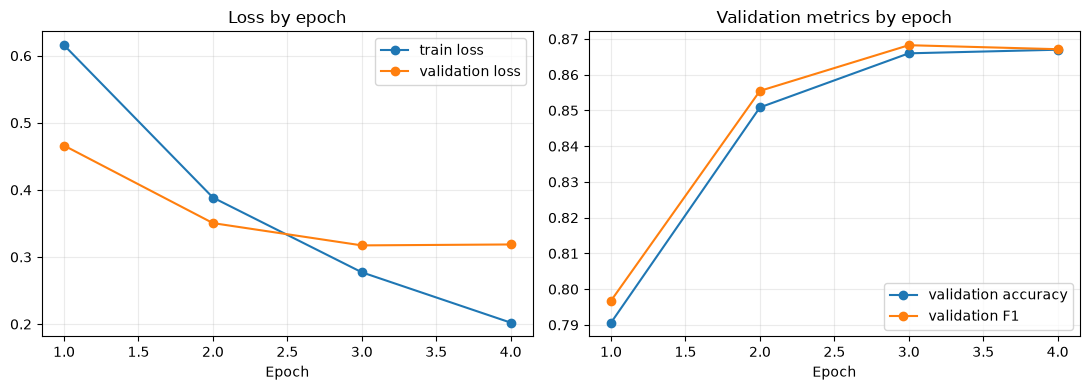

In [4]:
def tensors_for_batch(token_ids, lengths, labels, indices):
    batch_ids = torch.from_numpy(token_ids[indices]).long().to(device)
    batch_lengths = torch.from_numpy(lengths[indices]).to(device)
    batch_labels = torch.from_numpy(labels[indices]).to(device)
    return batch_ids, batch_lengths, batch_labels


def evaluate_model(model, token_ids, lengths, labels, batch_size):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), batch_size):
            indices = np.arange(start, min(start + batch_size, len(labels)))
            batch_ids, batch_lengths, batch_labels = tensors_for_batch(
                token_ids, lengths, labels, indices
            )
            logits = model(batch_ids, batch_lengths)
            loss = loss_function(logits, batch_labels)
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


batch_size = 256
epochs = 4
learning_rate = 1e-3
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
history = []
training_start = time.perf_counter()

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
        len(train_labels)
    )
    for start in range(0, len(train_labels), batch_size):
        indices = shuffled_indices[start:start + batch_size]
        batch_ids, batch_lengths, batch_labels = tensors_for_batch(
            train_ids, train_lengths, train_labels, indices
        )
        optimizer.zero_grad()
        logits = model(batch_ids, batch_lengths)
        loss = loss_function(logits, batch_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(indices)

    train_loss = epoch_loss / len(train_labels)
    validation_loss, validation_probabilities = evaluate_model(
        model,
        validation_ids,
        validation_lengths,
        validation_labels,
        batch_size,
    )
    validation_predictions = (validation_probabilities >= 0.5).astype(int)
    validation_accuracy = accuracy_score(
        validation_labels, validation_predictions
    )
    validation_f1 = f1_score(validation_labels, validation_predictions)
    history.append(
        {
            "epoch": epoch,
            "train loss": train_loss,
            "validation loss": validation_loss,
            "validation accuracy": validation_accuracy,
            "validation F1": validation_f1,
        }
    )
    print(
        f"Epoch {epoch:>2}/{epochs} | train loss {train_loss:.4f} | "
        f"validation loss {validation_loss:.4f} | "
        f"validation accuracy {validation_accuracy:.4f} | "
        f"validation F1 {validation_f1:.4f}"
    )

training_seconds = time.perf_counter() - training_start
history_frame = pd.DataFrame(history).set_index("epoch")
display(history_frame.style.format("{:.4f}"))
print(f"Training and validation time: {training_seconds:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["train loss", "validation loss"]].plot(
    ax=axes[0], marker="o"
)
history_frame[["validation accuracy", "validation F1"]].plot(
    ax=axes[1], marker="o"
)
axes[0].set_title("Loss by epoch")
axes[1].set_title("Validation metrics by epoch")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## Held-out test evaluation

The final fixed-epoch model is evaluated once on the untouched test split. Accuracy and F1 summarize overall classification, precision and recall expose error balance, and ROC AUC evaluates probability ranking independently of the 0.5 threshold.

,test score
loss,0.3157
accuracy,0.8669
precision,0.8680
recall,0.8666
F1,0.8673
ROC AUC,0.9400


              precision    recall  f1-score   support

    negative     0.8658    0.8672    0.8665      4939
    positive     0.8680    0.8666    0.8673      4977

    accuracy                         0.8669      9916
   macro avg     0.8669    0.8669    0.8669      9916
weighted avg     0.8669    0.8669    0.8669      9916



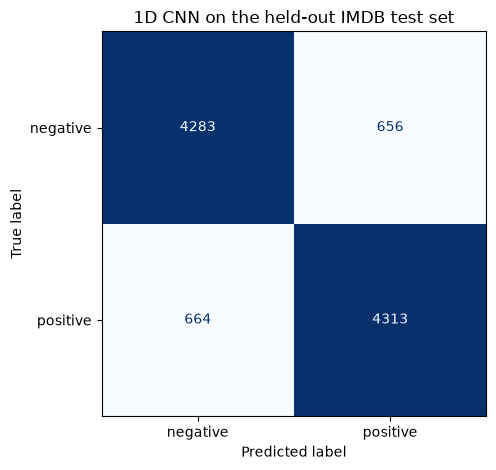

In [5]:
test_loss, test_probabilities = evaluate_model(
    model, test_ids, test_lengths, test_labels, batch_size
)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = pd.Series(
    {
        "loss": test_loss,
        "accuracy": accuracy_score(test_labels, test_predictions),
        "precision": precision_score(test_labels, test_predictions),
        "recall": recall_score(test_labels, test_predictions),
        "F1": f1_score(test_labels, test_predictions),
        "ROC AUC": roc_auc_score(test_labels, test_probabilities),
    },
    name="test score",
).to_frame()

display(test_metrics.style.format("{:.4f}"))
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("1D CNN on the held-out IMDB test set")
plt.tight_layout()
plt.show()

assert 0.0 <= test_metrics.loc["accuracy", "test score"] <= 1.0
assert len(test_predictions) == len(test_labels)

## Observations

The fixed four-epoch CNN reached test accuracy `0.8669`, precision `0.8680`, recall `0.8666`, F1 `0.8673`, and ROC AUC `0.9400`. Validation accuracy rose to `0.8670` at epoch 4, while validation loss was lowest at `0.3173` after epoch 3 and changed little at epoch 4 as training loss continued down to `0.2022`. This is the first mild sign that additional fixed epochs may widen the generalization gap.

The training-only 20,000-token vocabulary left `4.30%` of retained test tokens unknown. Truncating at 256 tokens affected `25.66%` of test reviews, which keeps the experiment practical but discards some long-range evidence. The compact CNN completed four training and validation epochs in `84.44` seconds on CPU and scored below the earlier TF-IDF MLP baseline, showing that local order-sensitive features are not automatically better than strong whole-document features without architecture or hyperparameter tuning.